In [2]:
import sys
import struct
import ctypes
from array import *
from ctypes import *
#OTO USB2.0 spectrameter's VID & PID
VID = 1592
PID = 2732
#OTOdll = CDLL("UserApplication.dll")
OTOdll = ctypes.cdll.LoadLibrary("./UserApplication.dll")
#Check how many device is connected with PC.
intDeviceamout = c_uint64(0)
OTOdll.UAI_SpectrometerGetDeviceAmount.restype = ctypes.c_uint64
OTOdll.UAI_SpectrometerGetDeviceAmount(VID,PID,byref(intDeviceamout))
print(f"Device amount: {intDeviceamout.value}")


if intDeviceamout.value < 1:
    print("NO device connecting")
    exit()


Device amount: 1


In [3]:
DeviceHandle = c_uint64(0)
OTOdll.UAI_SpectrometerOpen.restype = ctypes.c_uint64
OTOdll.UAI_SpectrometerOpen(0,byref(DeviceHandle),VID,PID)
print("Device handle:")
print(DeviceHandle.value)

Device handle:
2072234825600


In [8]:
intFramesize = c_uint64(0)
OTOdll.UAI_SpectromoduleGetFrameSize.restype = ctypes.c_uint64
OTOdll.UAI_SpectromoduleGetFrameSize(DeviceHandle,byref(intFramesize))
print("Device framesize:")
print(intFramesize.value)

Device framesize:
1237


In [5]:
charModulename = create_string_buffer(16)
OTOdll.UAI_SpectrometerGetModelName(DeviceHandle,byref(charModulename))
print ("Module name:")
print (repr(charModulename.value))

Module name:
b'SE1030-FUVN'


In [6]:
charSerialnumber = create_string_buffer(16)
OTOdll.UAI_SpectrometerGetSerialNumber(DeviceHandle,byref(charSerialnumber))
print ("Serial number:")
print (repr(charSerialnumber.value))

Serial number:
b'OS361AC55029501'


In [15]:
#Init array
#TempLambda = create_string_buffer(sizeof(c_float*intFramesize.value))
#TempIntensity = create_string_buffer(sizeof(c_float*intFramesize.value))
TempLambda = (c_float*intFramesize.value)()
TempIntensity = (c_float*intFramesize.value)()

#Get wavelength
OTOdll.UAI_SpectrometerWavelengthAcquire(DeviceHandle,byref(TempLambda))

Lambda = []
for i in range(0,intFramesize.value):
    Lambda.append(TempLambda[i])

Intensity = []

for i in range(1,100,+1):
    #Get Intensity
    OTOdll.UAI_SpectrometerDataOneshot(DeviceHandle,i*1000,byref(TempIntensity),1)

    #Do Background
    OTOdll.UAI_BackgroundRemove(DeviceHandle,i*1000,byref(TempIntensity))

    #Do Linearity# get the intensity I*1000 meaning
    OTOdll.UAI_LinearityCorrection(DeviceHandle,intFramesize,byref(TempIntensity))

    Intensity = []
    for i in range(0,intFramesize.value):
        Intensity.append(TempIntensity[i])
    print(Lambda[10] , Intensity[10])

# for loop to append different column as with differemt spectrum we obtain.
    #plot  wavelength as x intensity as y,

187.3013916015625 2.0093319416046143
187.3013916015625 6.298377990722656
187.3013916015625 -8.175981521606445
187.3013916015625 -2.5878098011016846
187.3013916015625 -7.361292839050293
187.3013916015625 -7.203638553619385
187.3013916015625 -6.885765075683594
187.3013916015625 5.317564487457275
187.3013916015625 3.505856990814209
187.3013916015625 5.684396266937256
187.3013916015625 4.016046524047852
187.3013916015625 10.60756778717041
187.3013916015625 5.636146068572998
187.3013916015625 -7.528715133666992
187.3013916015625 1.5429986715316772
187.3013916015625 8.49626350402832
187.3013916015625 -13.553635597229004
187.3013916015625 13.880064010620117
187.3013916015625 -0.5307779312133789
187.3013916015625 5.107880115509033
187.3013916015625 8.404040336608887
187.3013916015625 0.6718069314956665
187.3013916015625 14.193126678466797
187.3013916015625 -1.624276876449585
187.3013916015625 -7.994553565979004
187.3013916015625 3.014652967453003
187.3013916015625 -10.336447715759277
187.30139

In [42]:
import tkinter as tk
import sys
import struct
import ctypes
from array import *
from ctypes import *
#OTO USB2.0 spectrameter's VID & PID
VID = 1592
PID = 2732
OTOdll = ctypes.cdll.LoadLibrary("./UserApplication.dll")
def getDeviceHandle():
    DeviceHandle = c_uint64(0)
    OTOdll.UAI_SpectrometerOpen.restype = ctypes.c_uint64
    OTOdll.UAI_SpectrometerOpen(0,byref(DeviceHandle),VID,PID)
    print("Device handle:")
    print(DeviceHandle.value)
    device_info_box.insert(tk.END, f"Device handle:{DeviceHandle.value}\n")
    return DeviceHandle

def getDeviceFramesize(DeviceHandle):
    intFramesize = c_uint64(0)
    OTOdll.UAI_SpectromoduleGetFrameSize.restype = ctypes.c_uint64
    OTOdll.UAI_SpectromoduleGetFrameSize(DeviceHandle,byref(intFramesize))
    print("Device framesize:")
    print(intFramesize.value)
    device_info_box.insert(tk.END, f"Device framesize:{intFramesize.value}\n")
    return intFramesize

def getDevice():
    #Check how many device is connected with PC.
    global device_handle, device_framesize
    intDeviceamout = c_uint64(0)
    OTOdll.UAI_SpectrometerGetDeviceAmount.restype = ctypes.c_uint64
    OTOdll.UAI_SpectrometerGetDeviceAmount(VID,PID,byref(intDeviceamout))
    device_info_box.insert(tk.END, f"Device amount:{intDeviceamout.value}\n")
    device_handle = getDeviceHandle()
    device_framesize = getDeviceFramesize(device_handle)
    if intDeviceamout.value < 1:
        device_info_box.insert(tk.END, f"NO device connecting.\n")
        return 0, 0
    return device_handle, device_framesize


def function2():
    text_box.insert(tk.END, "Function 2 called\n")
    device_info_box.delete("1.0", tk.END)

# Create the main window
root = tk.Tk()
root.title("Spectrometer Interface")

# Create buttons
device_framesize = None
device_handle = None
button1 = tk.Button(root, text="Connect device", command=getDevice)
button1.pack()
# button1.grid(column=0,row=0)

button2 = tk.Button(root, text="Call Function 2", command=function2)
button2.pack()
# button2.grid(column=1,row=0)
# Create a text box
text_box = tk.Text(root, height=10, width=50)
text_box.pack()
quit_button = tk.Button(root, text="Quit", command=root.destroy)
quit_button.pack()
device_info_label = tk.Label(root, text="Device Information")
device_info_label.pack()
device_info_box = tk.Text(root, height=10, width=50)
device_info_box.pack()
handle, framesize = getDevice()
print(handle, framesize)
# Start the application
root.mainloop()


Device handle:
0
Device framesize:
0
0 0
Device handle:
0
Device framesize:
0
Device handle:
0
Device framesize:
0
Device handle:
0
Device framesize:
0
Device handle:
0
Device framesize:
0
Device handle:
0
Device framesize:
0
Device handle:
0
Device framesize:
0


In [16]:
##save file, number of spectrum to save, and path. as input to GUI
##

In [23]:
print(len(Lambda))
print(len(Intensity))


1237
1237


In [11]:
import csv
wave = [100, 200, 300, 400, 500, 600, 700, 800, 900]

def initilizingCache(waveLengthList):
    # Open a new CSV file for writing
    with open('./spectrometer_data_cache.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        waveLengthList = ["wavelength"]+waveLengthList

        # Writing the header (optional)
        writer.writerow(waveLengthList)

        # # Writing data
        # for wavelength in zip(waveLengthList):
        #     writer.writerow(wavelength)

initilizingCache(wave)

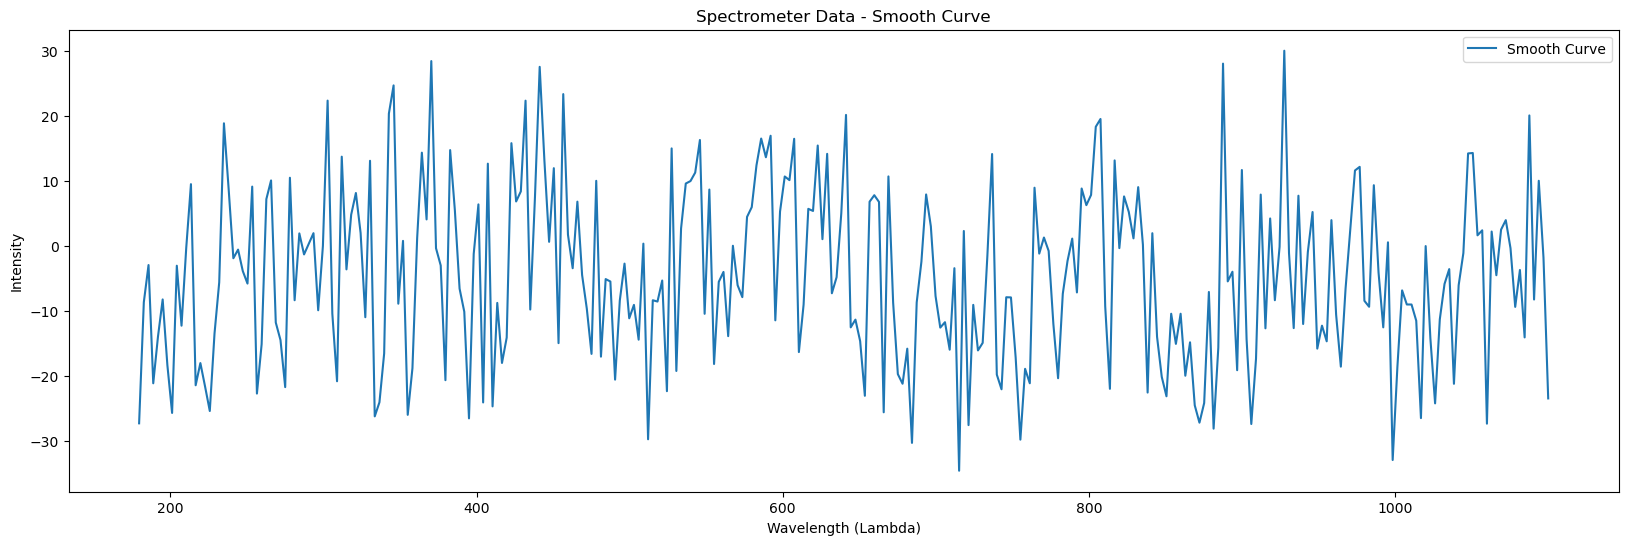

In [34]:
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Example data lists

# Convert lists to numpy arrays for scipy
Lambda_np = np.array(Lambda)
Intensity_np = np.array(Intensity)

# Interpolating data
spl = make_interp_spline(Lambda_np, Intensity_np, k=3)  # k is the degree of the spline
smooth_Lambda = np.linspace(Lambda_np.min(), Lambda_np.max(), 300)  # 300 points between Lambda.min and Lambda.max
smooth_Intensity = spl(smooth_Lambda)

# Create a plot with smooth curve
plt.figure(figsize=(20, 6))
plt.plot(smooth_Lambda, smooth_Intensity, label='Smooth Curve')
# plt.scatter(Lambda_np, Intensity_np, color='red', label='Original Data')  # Optional: plot the original data points

# Add titles and labels
plt.title("Spectrometer Data - Smooth Curve")
plt.xlabel("Wavelength (Lambda)")
plt.ylabel("Intensity")
plt.legend()

# Show the plot
plt.show()


In [37]:
import tkinter as tk

# Function to simulate fetching device information
def get_device_info():
    # Simulate fetching data
    # Replace this with your actual device information fetching logic
    device_info = "Device Model: XYZ\nFirmware Version: 1.0.3\nStatus: Connected"
    device_info_box.delete('1.0', tk.END)  # Clear existing text
    device_info_box.insert(tk.END, device_info)  # Insert new device info

# Function to simulate fetching device data
def get_device_data():
    # Simulate fetching data
    # Replace this with your actual device data fetching logic
    device_data = "Temperature: 22°C\nHumidity: 45%\nBattery Level: 80%"
    device_data_box.delete('1.0', tk.END)  # Clear existing text
    device_data_box.insert(tk.END, device_data)  # Insert new device data

# Set up the main window
root = tk.Tk()
root.title("Device Interface")

# Device information box
device_info_label = tk.Label(root, text="Device Information")
device_info_label.pack()
device_info_box = tk.Text(root, height=5, width=50)
device_info_box.pack()

# Device data box
device_data_label = tk.Label(root, text="Device Data")
device_data_label.pack()
device_data_box = tk.Text(root, height=5, width=50)
device_data_box.pack()

# Buttons to fetch information and data
fetch_info_button = tk.Button(root, text="Fetch Device Info", command=get_device_info)
fetch_info_button.pack()
fetch_data_button = tk.Button(root, text="Fetch Device Data", command=get_device_data)
fetch_data_button.pack()

# Start the GUI loop
root.mainloop()

In [10]:
import tkinter as tk

def my_function(data):
    device_info_box.insert(tk.END, f"Data received:{data}\n")
    print("Data received:", data)

root = tk.Tk()
data_to_pass = "Hello, World!"

button = tk.Button(root, text="Click Me", command=lambda: my_function(data_to_pass))
button.pack()
device_info_label = tk.Label(root, text="Device Information")
device_info_label.pack()
device_info_box = tk.Text(root, height=5, width=50)
device_info_box.pack()
root.mainloop()

Data received: Hello, World!
Data received: Hello, World!
Data received: Hello, World!
Data received: Hello, World!
Data received: Hello, World!
Data received: Hello, World!


In [14]:
def appendRow(filename, new_row, count):
    # Open the file in append mode and write the new row
    new_row = [f"Intensity of spectrum{count}"]+new_row
    with open(filename, 'a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(new_row)

# Example usage
new_data_row = ['700', '500']  # Replace with the wavelength and intensity data
appendRow('./spectrometer_data_cache.csv', new_data_row, 1)

In [24]:
import tkinter as tk
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

def plot(x_data, y_data):
    global canvas_widget
    # Create a figure
    fig = Figure(figsize=(5, 4), dpi=100)
    plot1 = fig.add_subplot(111)

    # Plot the data
    plot1.plot(x_data, y_data)
     # Destroy the existing canvas widget if it exists
    if canvas_widget is not None:
        canvas_widget.destroy()
    # Add figure to Tkinter window
    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas_widget = canvas.get_tk_widget()
    canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
    canvas.draw()

# Create main window
window = tk.Tk()
window.title("Matplotlib in Tkinter")
canvas_widget = None
# Example data lists
x_list = [100, 200, 300, 400, 500, 600, 700, 800]
y_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Button to display the plot
plot_button = tk.Button(master=window, command=lambda: plot(x_list, y_list), height=2, width=10, text="Plot")
plot_button.pack(side=tk.TOP)

# Run the application
window.mainloop()



In [23]:
import tkinter as tk
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ... [your existing code] ...

# Initialize a variable to keep track of the canvas widget


# Function to update or create the plot
def update_plot():
    global canvas_widget

    # Destroy the existing canvas widget if it exists
    # if canvas_widget is not None:
    #     canvas_widget.destroy()

    # Create a figure for the plot
    fig = Figure(figsize=(5, 4), dpi=100)
    ax = fig.add_subplot(111)
    ax.plot(Lambda, Intensity)  # Use your Lambda and Intensity lists here

    # Create the Matplotlib canvas and embed it in the Tkinter window
    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas_widget = canvas.get_tk_widget()
    canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)
    canvas.draw()

# [rest of your widgets]
canvas_widget = None
# Button to update the plot
plot_button = tk.Button(window, text="Update Plot", command=update_plot)
plot_button.pack()

# Start the application
window.mainloop()

TclError: can't invoke "button" command: application has been destroyed

In [29]:
import csv
def read_column_as_list(filename, column_index):
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        next(reader)  # Skip the header row
        return [float(row[column_index]) for row in reader if row]

# Example usage
filename = 'spectrometer_data.csv'  # Replace with your CSV file path
column_index = 1# Replace with the index of the column you want to read (0 for the first column)
column_data = read_column_as_list(filename, column_index)
print(column_data)

[-27.23872947692871, 27.26212501525879, -23.501203536987305, 10.08021354675293, -8.733341217041016, -16.68085289001465, -9.205168724060059, 1.94938325881958, -2.986361265182495, -9.389368057250977, 8.181674003601074, 7.597936630249023, -21.03627586364746, 17.653629302978516, 12.195651054382324, 1.0009483098983765, -13.941428184509277, 3.1403768062591553, 15.446560859680176, 7.211434841156006, -8.21192741394043, -0.8417176604270935, -1.8442081212997437, -0.1659078747034073, -18.312862396240234, 17.507658004760742, -31.422563552856445, -1.6356556415557861, -25.66166877746582, 4.577805519104004, -24.833986282348633, 8.580520629882812, -2.9000914096832275, -3.598325490951538, -30.39111328125, -27.22123146057129, -12.921744346618652, 15.695920944213867, -31.52356719970703, 1.3425030708312988, 0.1355375051498413, -5.695924282073975, 8.278328895568848, 5.226321697235107, 9.049600601196289, 12.690546989440918, -18.493682861328125, -7.309994220733643, -21.638742446899414, 2.5324819087982178, 4.

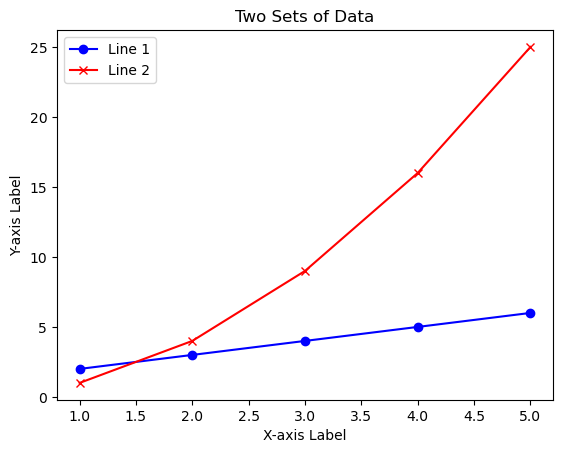

In [2]:
import matplotlib.pyplot as plt

# Sample data
x1_data = [1, 2, 3, 4, 5]
y1_data = [2, 3, 4, 5, 6]

x2_data = [1, 2, 3, 4, 5]
y2_data = [1, 4, 9, 16, 25]

# Create a new figure (optional if you have only one plot)
plt.figure()

# Plot the first set of data
plt.plot(x1_data, y1_data, label='Line 1', color='blue', linestyle='-', marker='o')

# Plot the second set of data
plt.plot(x2_data, y2_data, label='Line 2', color='red', linestyle='-', marker='x')

# Adding legend, title, and labels
plt.legend()
plt.title("Two Sets of Data")
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")

# Show the plot
plt.show()


In [1]:
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import random

def update_plot():
    if update_active:
        # Clear the current plot
        ax.clear()

        # Generate some new data (for example purposes)
        new_data = [random.random() for _ in range(10)]

        # Plot the new data
        ax.plot(new_data, marker='o', color='blue')

        # Redraw the canvas
        canvas.draw()

        # Schedule the next update
        root.after(50, update_plot)

def start_updating():
    global update_active
    update_active = True
    update_plot()

def stop_updating():
    global update_active
    update_active = False

# Initialize Tkinter window
root = tk.Tk()

# Create the figure and ax
fig = Figure(figsize=(5, 4), dpi=100)
ax = fig.add_subplot(111)

# Create and pack the canvas
canvas = FigureCanvasTkAgg(fig, master=root)
canvas_widget = canvas.get_tk_widget()
canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

# Flag to control the update
update_active = False

# Start and Stop buttons
start_button = tk.Button(root, text="Start", command=start_updating)
start_button.pack(side=tk.LEFT)

stop_button = tk.Button(root, text="Stop", command=stop_updating)
stop_button.pack(side=tk.RIGHT)

root.mainloop()
